In [ ]:
import numpy as np;
import pandas as pd;
import seaborn as sns;
import matplotlib.pyplot as plt;
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df=sns.load_dataset("titanic")

In [3]:
df.drop_duplicates(inplace=True)
df.isnull().sum()

survived         0
pclass           0
sex              0
age            106
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           582
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
df.tail()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
885,0,3,female,39.0,0,5,29.125,Q,Third,woman,False,NaN,Queenstown,no,False
887,1,1,female,19.0,0,0,30.000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.450,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.000,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.750,Q,Third,man,True,NaN,Queenstown,no,True


In [5]:
df=df.drop(['who','adult_male','embarked','deck','alive','alone'],axis=1)


In [6]:
df.columns
print(df.dtypes)



survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
class          category
embark_town      object
dtype: object


In [7]:
co=['survived','pclass','sex', 'age','sibsp','parch','fare','class','embark_town']
for n in co:
    print(df[co].value_counts(dropna=False))



survived  pclass  sex     age   sibsp  parch  fare     class   embark_town
0         1       male    NaN   0      0      0.0000   First   Southampton    2
                          62.0  0      0      26.5500  First   Southampton    2
          3       male    NaN   0      0      7.7500   Third   Queenstown     2
1         2       female  36.0  0      0      13.0000  Second  Southampton    2
0         1       female  50.0  0      0      28.7125  First   Cherbourg      1
                                                                             ..
1         3       male    NaN   0      0      7.7750   Third   Southampton    1
                                              8.1125   Third   Southampton    1
                                              56.4958  Third   Southampton    1
                                1      1      15.2458  Third   Cherbourg      1
                                2      0      23.2500  Third   Queenstown     1
Name: count, Length: 780, dtype: int64
surviv

In [8]:
df.dropna(subset=['embark_town'],inplace=True)

In [9]:
df['age']=df['age'].fillna(df['age'].median())

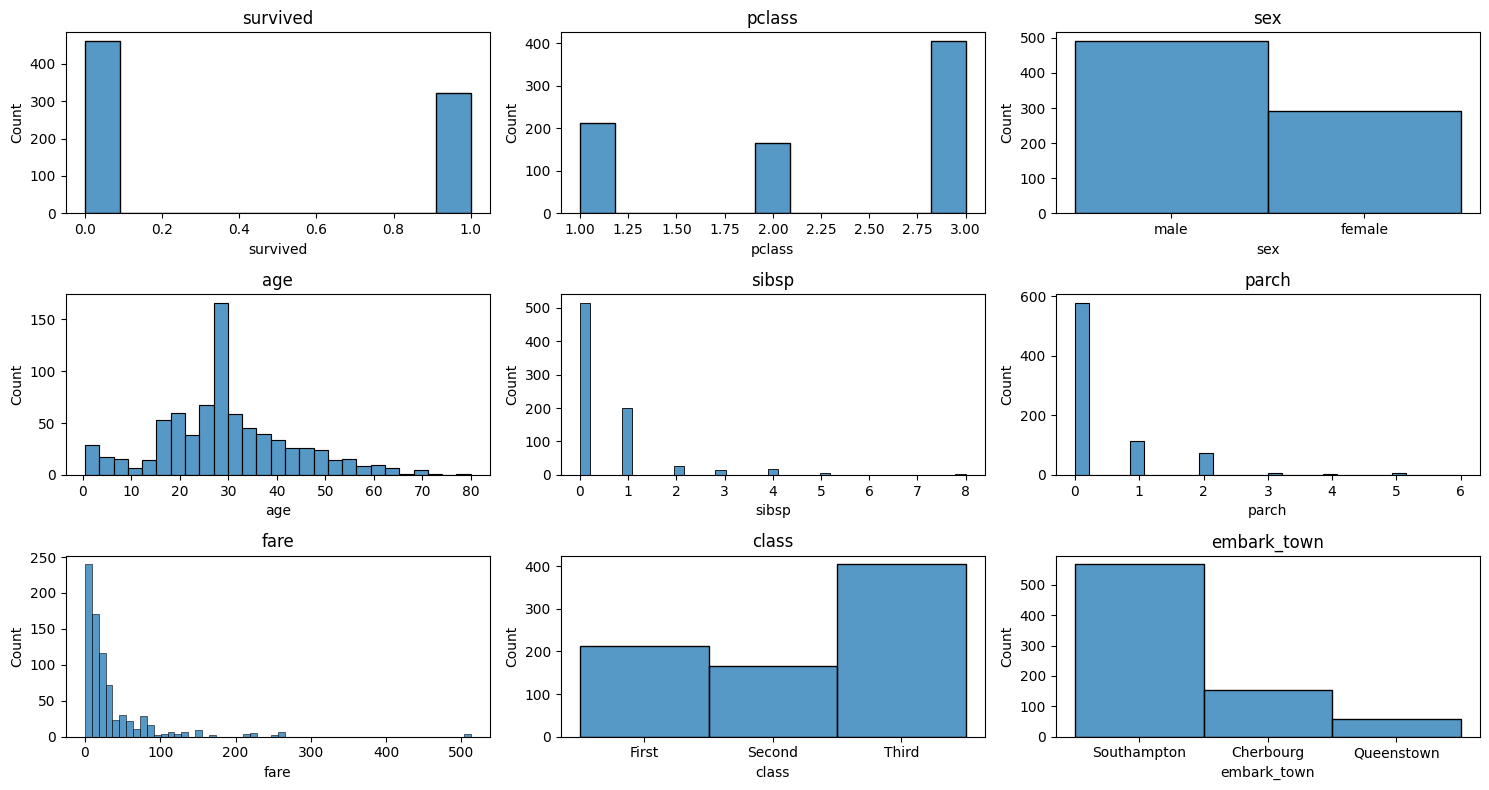

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 8))

for i, col in enumerate(co):
    sns.histplot(x=col, data=df, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(col)

plt.tight_layout()
plt.show()


In [11]:
df['sex']=df['sex'].replace({'male':1,'female':0})


In [12]:
cotosca=['pclass','age', 'sibsp', 'parch', 'fare']
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
for x in cotosca:
    df[x]=scaler.fit_transform(df[[x]])



In [13]:
df.rename(columns={'sex':'ismale'},inplace=True)

In [14]:
dfa=df.copy()

In [15]:
from sklearn.preprocessing import LabelEncoder
en=LabelEncoder()
coms=['class', 'embark_town']
for x in coms:
    df[x]=en.fit_transform(df[x])
    df[x]=scaler.fit_transform(df[[x]])


In [16]:
dfa=pd.get_dummies(dfa,columns=['class', 'embark_town'])
dmy=dfa.select_dtypes(include='bool').columns
for x in dmy:
    dfa[dmy]=dfa[dmy].astype(int)





In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
x=df.drop('survived',axis=1)
y=df['survived']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
model=LogisticRegression()
model.fit(x_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy_score(y_test,y_pred)


0.7643312101910829

In [19]:
confusion_matrix(y_test,y_pred)

array([[70, 18],
       [19, 50]])

In [20]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.80      0.79        88
           1       0.74      0.72      0.73        69

    accuracy                           0.76       157
   macro avg       0.76      0.76      0.76       157
weighted avg       0.76      0.76      0.76       157



In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
x=dfa.drop('survived',axis=1)
y=dfa['survived']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
model2=LogisticRegression()
model2.fit(x_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
y_pred=model2.predict(x_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy_score(y_test,y_pred)


0.7834394904458599

In [23]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81        88
           1       0.77      0.72      0.75        69

    accuracy                           0.78       157
   macro avg       0.78      0.78      0.78       157
weighted avg       0.78      0.78      0.78       157



In [24]:
confusion_matrix(y_test,y_pred)

array([[73, 15],
       [19, 50]])

In [25]:
from sklearn.neighbors import KNeighborsClassifier
model3=KNeighborsClassifier(n_neighbors=5)
model3.fit(x_train,y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
y_pred=model3.predict(x_test)
accuracy_score(y_test,y_pred)


0.7452229299363057

In [27]:
confusion_matrix(y_test,y_pred)

array([[74, 14],
       [26, 43]])

In [28]:
from sklearn.naive_bayes import GaussianNB
model4=GaussianNB()
model4.fit(x_train,y_train)


,priors,None
,var_smoothing,1e-09


In [29]:
y_pred=model4.predict(x_test)
accuracy_score(y_test,y_pred)


0.7006369426751592

In [30]:
confusion_matrix(y_test,y_pred)

array([[67, 21],
       [26, 43]])

In [31]:
model4.get_params()

{'priors': None, 'var_smoothing': 1e-09}

In [56]:
from sklearn.model_selection import GridSearchCV
classfer=GridSearchCV(model4,{
    'priors':[None,[0.1,0.9],[0.5,0.5]],
    'var_smoothing':[1e-9,1e-8,1e-6]
},cv=20,scoring='accuracy')

In [57]:
classfer.fit(x,y)

,estimator,GaussianNB()
,param_grid,"{'priors': [None, [0.1, 0.9], ...], 'var_smoothing': [1e-09, 1e-08, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,20
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,priors,None


In [58]:
classfer.best_params_

{'priors': None, 'var_smoothing': 1e-09}

In [59]:
classfer.best_score_

np.float64(0.7354807692307693)

In [60]:
from sklearn.model_selection import RandomizedSearchCV
classfer=RandomizedSearchCV(model4,{
    'priors':[None,[0.1,0.9],[0.5,0.5]],
    'var_smoothing':[1e-9,1e-8,1e-6]
},cv=20,scoring='accuracy',n_iter=2)

In [61]:
classfer.fit(x,y)

,estimator,GaussianNB()
,param_distributions,"{'priors': [None, [0.1, 0.9], ...], 'var_smoothing': [1e-09, 1e-08, ...]}"
,n_iter,2
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,20
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [62]:
classfer.best_score_

np.float64(0.7354807692307693)